## Differential Evolution

In this session, we will discover how Differential Evolution (DE) works. We will explore the underlying principles, implement core components from scratch, apply DE to classic benchmark functions, visualize its dynamics through a generated GIF, and tackle constraints.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.collections import PathCollection
from typing import Callable
from dataclasses import dataclass

### Optimization Problems

This cell defines three common benchmark functions, Sphere, Rosenbrock, and Rastrigin, used to test optimization algorithms. We also used these functions earlier to evaluate Adam, Momentum, and CMA-ES.

In [2]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))


def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1.0 - x[:-1]) ** 2.0))


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))

BOUNDS = [(-5, 5), (-5, 5)]

### Differential Evolution

Differential Evolution is a simple yet powerful **population-based search algorithm** for continuous optimization. At every iteration it maintains a population of $pop\_size$ candidate solutions, each an $n$-dimensional real-valued vector. Three straightforward operators: mutation, crossover, and selection, are applied to push the population toward regions of lower objective value.

#### 1. Initialisation  
Randomly sample $pop\_size$ vectors inside the problem's bounds.

#### 2. Mutation  
For each target vector $x_i$:

1. Select three distinct solutions $a$, $b$, $c$ (none equal to $x_i$) from current population.  
2. Create the mutant  
   $$v = a + F\,(b - c)$$
   where $F \in (0.4,1^+)$ is the scaling factor. The difference $(b-c)$ supplies direction and scale; $F$ stretches or shrinks the step.

#### 3. Crossover  
Blend the mutant $v$ with its target $x_i$ to form the trial vector \(u\):

- For each coordinate $j$, copy $v_j$ into $u_j$ with probability $CR$; otherwise copy $x_{i,j}$.  
- Force at least one coordinate to come from $v$ so that $u \neq x_i$.

Here $CR \in [0,1]$ is the *crossover rate*: higher $CR$ means aggressive mixing; lower $CR$ leaves the mutant mostly intact.

#### 4. Selection  
Evaluate the objective $f(\cdot)$: $u \text{ replaces } x_i \quad \text{if} \quad f(u) < f(x_i)$

Greedy replacement ensures the population does not deteriorate.

#### 5. Iteration & Termination  
After every target has produced a trial and selection is done, the new population is complete. Repeat until a generation limit, a fitness threshold, or a stall criterion is reached.

#### 6. Parameter intuition  

| Parameter | Typical range |
|-----------|---------------|
| Differential weight \(F\) | 0.4 – 1.0 |
| Crossover rate \(CR\)     | 0.1 – 0.9 |
| Population size \(P\)     | $5n$ – $10n$ |

In [15]:
@dataclass
class DEResult:
    best_vector: np.ndarray
    best_value: float
    history: list[np.ndarray] # History of populations for animation
    convergence_curve: list[float]


def differential_evolution(
    func: Callable[[np.ndarray], float],
    bounds: list[tuple[float, float]] = BOUNDS,
    pop_size: int = 50,
    F: float = 0.8,
    CR: float = 0.9,
    max_gen: int = 100,
    seed: int | None = None,
) -> DEResult:
    """
    Implements the Differential Evolution algorithm for global optimization.

    Parameters:
        func: Objective function to minimize. Takes a numpy array and returns a float.
        bounds: list of (min, max) pairs for each dimension.
        pop_size: Number of individuals in the population.
        F: Mutation factor (typically in [0.4, 1.0]).
        CR: Crossover rate (typically in [0, 1]).
        max_gen: Maximum number of generations to evolve.
        seed: Optional RNG seed for reproducible runs.
    """
    np.random.seed(seed)
    dimensions = len(bounds)
    lower_bounds = np.array([b[0] for b in bounds])
    upper_bounds = np.array([b[1] for b in bounds])
    
    # --- TODO: Exercise 1 - Initialization ---
    # Initialize the population: Create pop_size individuals.
    population = lower_bounds + np.random.rand(pop_size, dimensions) * (upper_bounds - lower_bounds)
    # Each individual is a vector of 'dimensions' length.
    # Use uniform distribution to sample the initial population.
    fitness = np.array([func(ind) for ind in population])

    history = [population.copy()]

    convergence_curve = [np.min(fitness)]
    # --- End Exercise 1 ---

    for generation in range(max_gen):
        new_population = np.zeros_like(population)
        new_fitness = np.zeros_like(fitness)

        for i in range(pop_size):
            target_vector = population[i]
            
            # --- TODO: Exercise 2 - Mutation ---
            # Select three distinct random individuals (a, b, c) from the population,
            # different from the current target_vector at index i.
            # Ensure indices are unique and not equal to i.
            # Create the mutant vector: v = a + F * (b - c)
            #
            # Boundary handling: the mutant may fall outside `bounds`. Use the
            # simplest strategy and clip each coordinate back into its
            # [lower, upper] range with `np.clip`.

            candidates = [idx for idx in range(pop_size) if idx != i]
            a_idx, b_idx, c_idx = np.random.choice(candidates, 3, replace=False)

            a = population[a_idx]
            b = population[b_idx]
            c = population[c_idx]

            mutant_vector = a + F * (b - c)
            mutant_vector = np.clip(mutant_vector, lower_bounds, upper_bounds)



            # --- End Exercise 2 ---

            # --- TODO: Exercise 3 - Crossover ---
            # Create the trial vector by performing crossover between the target_vector and the mutant_vector.
            # For each dimension j:
            #   Pick a random number r from [0,1).
            #   If r < CR or j == j_rand (where j_rand is a randomly chosen dimension index),
            #     trial_vector[j] = mutant_vector[j]
            #   Else:
            #     trial_vector[j] = target_vector[j]
            # Ensure at least one dimension comes from the mutant vector (j_rand ensures this).

            trial_vector = np.copy(target_vector)
            j_rand = np.random.randint(0, dimensions)

            for j in range(dimensions):
                r = np.random.rand()
                if r < CR or j == j_rand:
                    trial_vector[j] = mutant_vector[j]
                else:
                    trial_vector[j] = target_vector[j]



            # --- End Exercise 3 ---
            
            # --- TODO: Exercise 4 - Selection ---
            # Evaluate the trial vector.
            # If the trial vector is better than or equal to the target vector,
            #   replace the target vector with the trial vector in the new_population and update its fitness.
            # Else, keep the target vector.

            trial_fitness = func(trial_vector)
            if trial_fitness <= fitness[i]:
                new_population[i] = trial_vector
                new_fitness[i] = trial_fitness
            else:
                new_population[i] = target_vector
                new_fitness[i] = fitness[i]
        
        population = new_population
        fitness = new_fitness
        history.append(population.copy())
        convergence_curve.append(np.min(fitness))

    best_idx = np.argmin(fitness)

    return DEResult(best_vector=population[best_idx], best_value=fitness[best_idx], history=history, convergence_curve=convergence_curve)


            # --- End Exercise 4 ---

### Test implemented DE

In [8]:
result = differential_evolution(sphere, bounds=BOUNDS, pop_size=50)

### Visualizing Search Dynamics

In [9]:
def animate_de(
    func: Callable[[np.ndarray], float],
    history: list[np.ndarray],
    bounds: list[tuple[float, float]] = BOUNDS,
    frames: int | None = None,
    filename: str = "de_animation.gif",
) -> None:
    """
    Creates and saves a GIF showing how the DE population moves over generations.
    """
    if frames is None:
        frames = len(history)

    assert len(bounds) == 2, "This function only supports 2D visualization (expected 2 bounds)."
    x_bounds = (bounds[0][0], bounds[0][1])
    y_bounds = (bounds[1][0], bounds[1][1])

    x = np.linspace(x_bounds[0], x_bounds[1], 200)
    y = np.linspace(y_bounds[0], y_bounds[1], 200)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    Z = np.array([func(pt) for pt in coords]).reshape(X.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(X, Y, Z, levels=20, cmap="viridis")
    fig.colorbar(contour, ax=ax)

    # Track only the scatters we add so we can remove them between frames
    # without touching the contour (works across matplotlib versions).
    scatters: list = []

    def update(i: int):
        while scatters:
            scatters.pop().remove()

        ax.set_title(f"Generation {i}")

        DECAY_CONSTANT = 10

        # Plot all generations up to i, with alpha decreasing for older points
        for j in range(i + 1):
            age = i - j
            alpha = float(np.exp(-age / DECAY_CONSTANT))
            pop_j = history[j]
            scatters.append(
                ax.scatter(pop_j[:, 0], pop_j[:, 1], s=24, color="red", edgecolors="none", alpha=alpha)
            )

        # Return an empty tuple since we're redrawing everything
        return ()

    ax.set_xlim(x_bounds[0], x_bounds[1])
    ax.set_ylim(y_bounds[0], y_bounds[1])

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=200,
        blit=False,  # must be False since we redraw each frame
    )

    writer = animation.PillowWriter(fps=5)
    anim.save(filename, writer=writer)
    plt.close(fig)
    print(f"Animation saved to {filename}")

In [10]:
animate_de(func=sphere, history=result.history)

Animation saved to de_animation.gif


### Experiments
Run DE on all three problems: Sphere, Rosenbrock and Rastrigin. For each problem:
- Generate and analyze convergence plots showing the progression of the best fitness value over iterations.
- Visualize the population dynamics over time to illustrate how the search space is explored and exploited.

Sphere Best Value: 1.4072199022248725e-17
Rosenbrock Best Value: 1.5963298462457038e-11
Rastrigin Best Value: 1.7412205366440503e-07


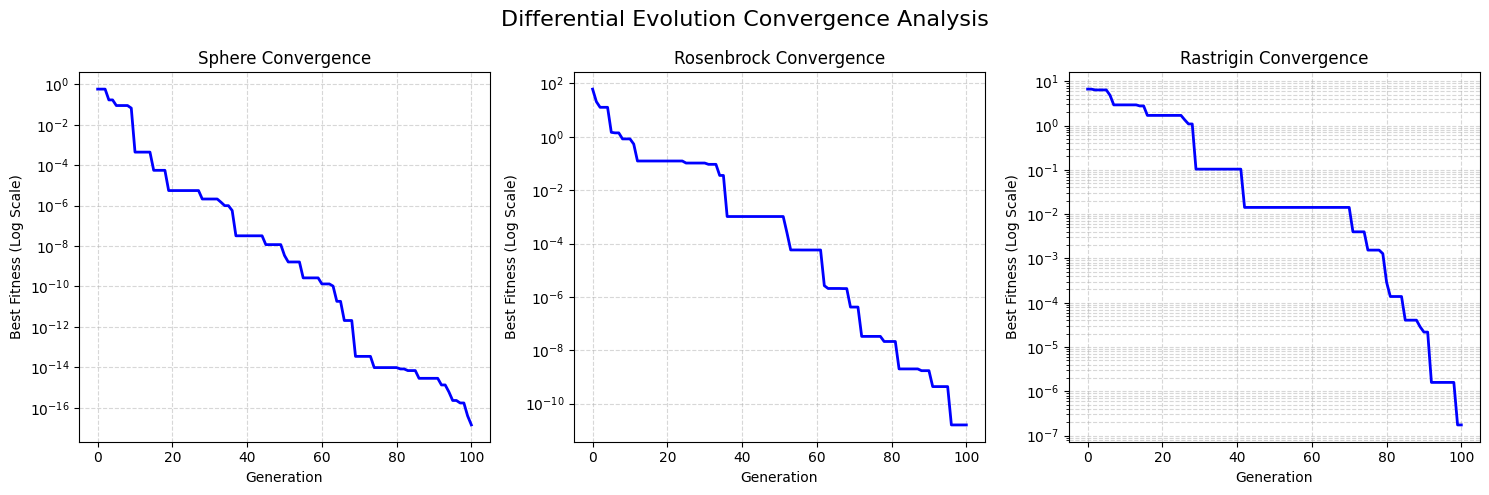

Animation saved to dynamics_sphere.gif
Animation saved to dynamics_rosenbrock.gif
Animation saved to dynamics_rastrigin.gif


In [ ]:
def run_experiments():
    problems = {
        "Sphere": sphere,
        "Rosenbrock": rosenbrock,
        "Rastrigin": rastrigin
    }
    
    results = {}
    
    for name, func in problems.items():
        results[name] = differential_evolution(func, seed=42)
        print(f"{name} Best Value: {results[name].best_value}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Differential Evolution Convergence Analysis", fontsize=16)
    
    for ax, (name, res) in zip(axes, results.items()):
        ax.plot(res.convergence_curve, color='blue', linewidth=2)
        ax.set_yscale('log')
        ax.set_title(f"{name} Convergence")
        ax.set_xlabel("Generation")
        ax.set_ylabel("Best Fitness (Log Scale)")
        ax.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    for name, res in results.items():
        animate_de(
            func=problems[name], 
            history=res.history, 
            bounds=BOUNDS, 
            filename=f"dynamics_{name.lower()}.gif"
        )

run_experiments()

Sphere 

Because this landscape is a perfectly smooth, the algorithm spends almost no time exploring. Once the initial random population realizes that every "downhill" direction points toward the center, it immediately shifts into exploitation. The vectors rapidly shrink into a single, dense point at the global minimum, which is why your convergence plot shows a fast, uninterrupted drop.


Rosenbrock 

The algorithm performs a quick burst of exploration to dive off the steep walls and into the valley. Once on the flat floor, it is forced into cautious exploitation. The population forms a curved line and takes tiny, careful steps to slide toward the minimum without bouncing up the steep walls.

Rastrigin

The algorithm relies on sustained exploration, with different sub-groups of the population getting stuck in various shallow pits. During these periods, the convergence graph flatlines. However, when the mutation and crossover steps serendipitously combine vectors from two different pits to discover a deeper pit, the algorithm temporarily switches to exploitation, swarming the new location. This cycle of getting stuck and breaking free creates the distinct "staircase" pattern on the graph.

### Hyperparameters in Differential Evolution

Two hyperparameters drive DE's exploration/exploitation tradeoff:

- **Scaling factor $F$** controls the magnitude of the differential mutation step. Large $F$ → big jumps (exploration); small $F$ → small refinements (exploitation).
- **Crossover rate $CR$** controls how much of the mutant ends up in the trial vector. Large $CR$ → aggressive mixing across coordinates; small $CR$ → trial mostly inherits the target.

#### Task: $F \times CR$ grid search on Rastrigin

Rastrigin is highly multimodal, so it is a good stress test for these knobs. Run a grid over

- $F \in \{0.3,\ 0.5,\ 0.7,\ 0.9\}$
- $CR \in \{0.1,\ 0.3,\ 0.5,\ 0.7,\ 0.9\}$

For each $(F, CR)$ pair, run DE **5 times** with different seeds on **10D Rastrigin** (`bounds = [(-5, 5)] * 10`, `pop_size = 50`, `max_gen = 200`) and record the best final fitness. Aggregate by mean across seeds.

**Deliverables**

1. A heatmap of mean best fitness over the $F \times CR$ grid (e.g. `plt.imshow` with annotated cells, or `seaborn.heatmap`).
2. A short written analysis (3–5 sentences):
   - Which region of the grid performs best, and why?
   - What happens at the extreme corners (low $F$ + low $CR$; high $F$ + high $CR$)?
   - How does the answer connect to the exploration/exploitation framing above?

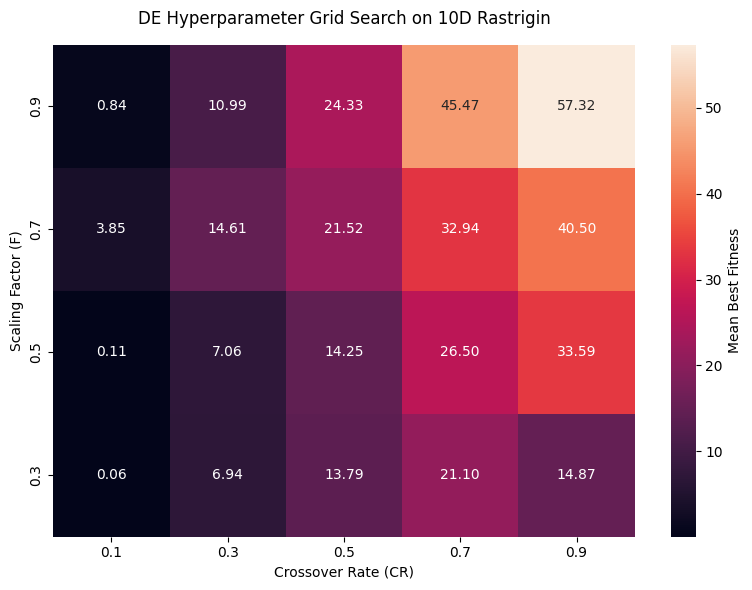

In [28]:
import seaborn as sns
def run_grid_search():
    F_values = [0.3, 0.5, 0.7, 0.9]
    CR_values = [0.1, 0.3, 0.5, 0.7, 0.9]
    seeds = [42, 43, 44, 45, 46]
    
    bounds = [(-5.0, 5.0)] * 10
    pop_size = 50
    max_gen = 200
    
    results_grid = np.zeros((len(F_values), len(CR_values)))
    
    for i, F in enumerate(F_values):
        for j, CR in enumerate(CR_values):
            run_results = []
            for seed in seeds:
                res = differential_evolution(rastrigin, bounds, pop_size, F, CR, max_gen, seed)
                run_results.append(res.best_value)
            
            results_grid[i, j] = np.mean(run_results)

    
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(results_grid, annot=True, fmt=".2f",
                     xticklabels=CR_values, yticklabels=F_values, 
                     cbar_kws={'label': 'Mean Best Fitness'})
    
    plt.title("DE Hyperparameter Grid Search on 10D Rastrigin", pad=15)
    plt.xlabel("Crossover Rate (CR)")
    plt.ylabel("Scaling Factor (F)")
    ax.invert_yaxis() 
    plt.tight_layout()
    plt.show()


run_grid_search()

The best performance occurs in the region of low $CR$ (0.1) and low-to-moderate $F$ (0.3 - 0.5). Because the 10D Rastrigin function is highly multimodal but separable, a low $CR$ is highly effective; it allows the algorithm to conservatively mutate only 1 or 2 dimensions at a time, optimizing independent coordinates without destroying the good genetic material in others. Conversely, the extreme corner of high $F$ and high $CR$ performs terribly because changing all 10 dimensions simultaneously with large step sizes leads to chaotic over-exploration, preventing the algorithm from settling into the global basin. This illustrates a nuance in the exploration/exploitation tradeoff - for separable multimodal problems, conservative mixing (low exploration across dimensions via low $CR$) paired with moderate step sizes allows for safer, dimension-by-dimension exploitation.

### SHADE: Success-History Based Adaptive Differential Evolution

SHADE is an advanced variant of DE designed to enhance optimization performance through adaptive parameter control. Your task is to critically analyze the research paper [Success-History Based Parameter Adaptation for Differential Evolution](https://metahack.org/CEC2013-SHADE.pdf).
- Summarize the key concepts and mechanisms introduced in SHADE.
- Explain how SHADE differs from the standard DE algorithm.
- Discuss the motivation behind these changes and the empirical improvements demonstrated in the study.

SHADE introduces a Historical Memory Array. When individuals succeed, their Scaling Factor ($F$) and Crossover Rate ($CR$) are saved to this array. Future generations sample their parameters directly from this memory using statistical distributions.

Standard DE forces the user to guess fixed $F$ and $CR$ values that stay static the entire run. SHADE self-adapts these parameters for every individual in every generation. It also uses a "greedier" mutation strategy (anchored to the top performers) while maintaining an external archive of older solutions to prevent premature convergence.

It was built to fix a major flaw in its predecessor, JADE. JADE took an average of all successful parameters. On complex problems, averaging a high $F$ and a low $F$ yields a middle $F$ that might be completely useless. SHADE’s memory array solves this by preserving multiple distinct successful "modes" at once.
SHADE essentially eliminated the need for manual hyperparameter tuning. It proved significantly more robust on multimodal and non-separable problems, dominating the state-of-the-art algorithms on the difficult CEC 2013 benchmark suite.

### Recommended Reading
1. https://pablormier.github.io/2017/09/05/a-tutorial-on-differential-evolution-with-python/
2. Das, Swagatam, and Ponnuthurai Nagaratnam Suganthan. [Differential evolution: A survey of the state-of-the-art.](https://i2pc.es/coss/Docencia/SignalProcessingReviews/Das2011.pdf)
3. Tanabe, Ryoji, and Alex Fukunaga. [Success-history based parameter adaptation for differential evolution.](https://metahack.org/CEC2013-SHADE.pdf)